# Validação de Modelos e métodos automáticos
- Holdout vs. Sem Holdout 
- Métricas penalizadas por complexidade – Para casos com poucos dados (BIC, AIC).
- Métricas para avaliação no holdout – ASE, MAE, MAPE, RMSE.
- Auto ARIMA 

In [1]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
from funcoes import all_ac, plot_forecast, teste_estacionariedade, diagnostico, compara_previsoes, correlacao_cruzada, compara_estatisticas
plt.rcParams["figure.figsize"] = [12, 5]
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
import pmdarima as pm
from statsmodels.datasets import co2, get_rdataset

<Axes: xlabel='month'>

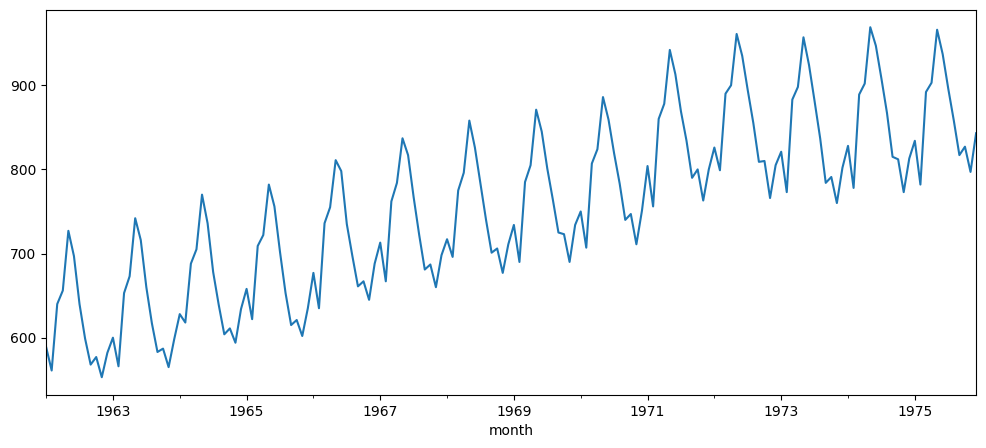

In [2]:
milk = pd.read_csv('/Users/danielferreira/Documents/git/classes/ASN/Séries Temporais/dados/milk_production.csv')
milk.index = pd.to_datetime(milk['month'])
milk.index.freq = 'MS'
milk_prod = pd.Series(milk['production'], name="produção de leite")
milk_prod.plot()

## Holdout

In [3]:
train, test = pm.model_selection.train_test_split(milk_prod, test_size=0.10)
train

month
1962-01-01    589
1962-02-01    561
1962-03-01    640
1962-04-01    656
1962-05-01    727
             ... 
1974-03-01    889
1974-04-01    902
1974-05-01    969
1974-06-01    947
1974-07-01    908
Freq: MS, Name: produção de leite, Length: 151, dtype: int64

In [4]:
len(milk_prod)/10

16.8

In [5]:
periodos = 24
train = milk_prod[:-periodos]
test = milk_prod[-periodos:]
train

month
1962-01-01    589
1962-02-01    561
1962-03-01    640
1962-04-01    656
1962-05-01    727
             ... 
1973-08-01    837
1973-09-01    784
1973-10-01    791
1973-11-01    760
1973-12-01    802
Freq: MS, Name: produção de leite, Length: 144, dtype: int64

## Métricas calculadas no holdout


                                      SARIMAX Results                                       
Dep. Variable:                    produção de leite   No. Observations:                  144
Model:             SARIMAX(1, 1, 0)x(0, 1, [1], 12)   Log Likelihood                -452.127
Date:                              Tue, 25 Mar 2025   AIC                            910.254
Time:                                      17:25:51   BIC                            918.879
Sample:                                  01-01-1962   HQIC                           913.759
                                       - 12-01-1973                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2660      0.086     -3.085      0.002      -0.435      -0.097
ma.S.L12      -0.63

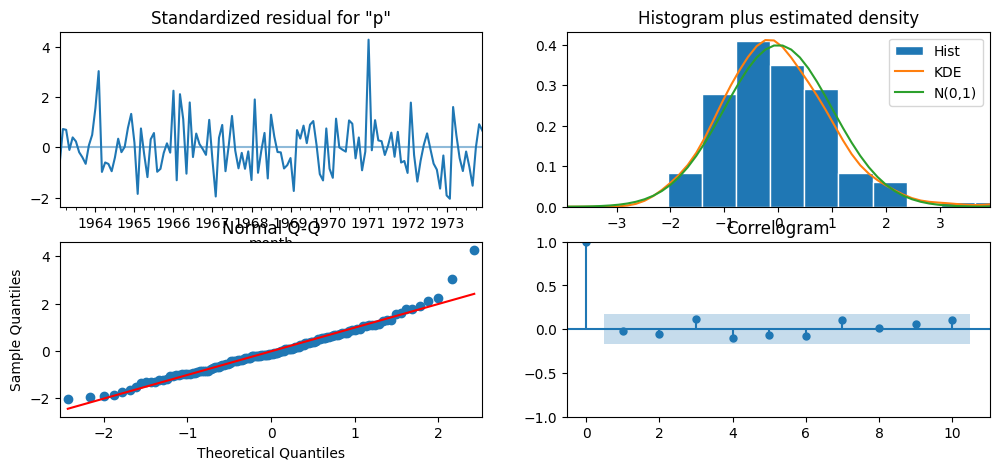

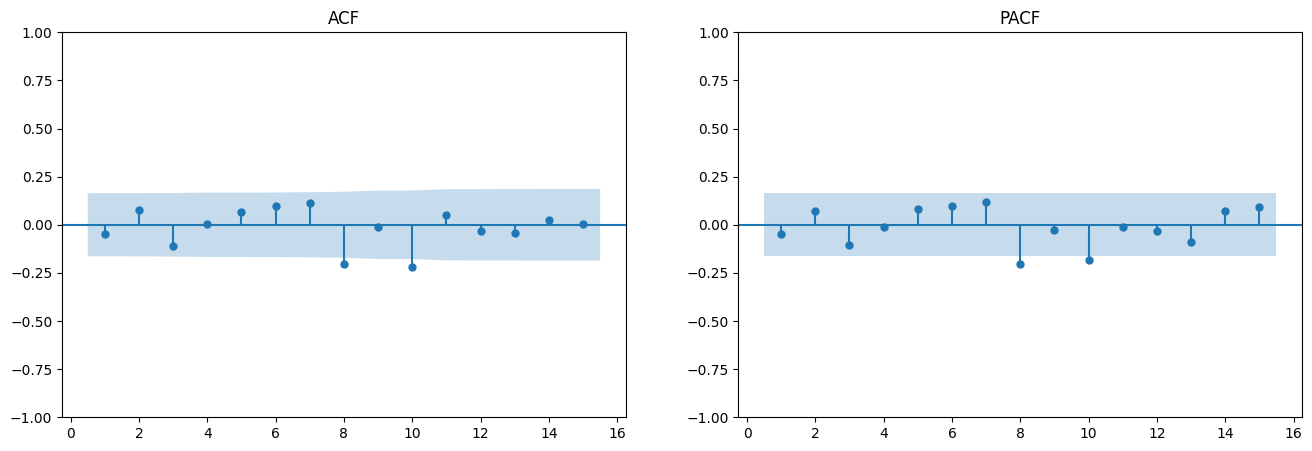

In [6]:
model = SARIMAX(train, order = (1,1,0), seasonal_order=(0,1,1,12)).fit(disp=False)
diagnostico(model)

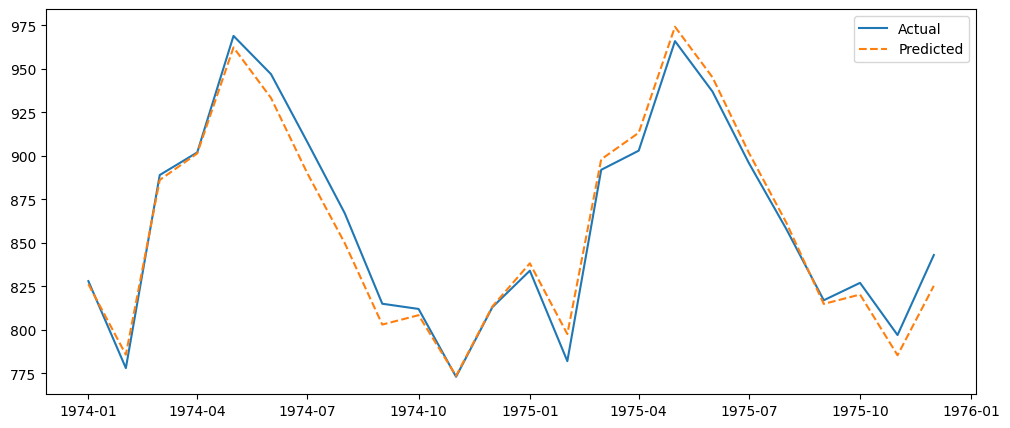

In [7]:
predictions = model.predict(start=test.index[0], end=test.index[-1], dynamic=False)
plt.plot(test, label='Actual')
plt.plot(predictions, label='Predicted', linestyle='--')
plt.legend()
plt.show()

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
residuals = test - predictions
sum_residuals = residuals.sum()
mae = mean_absolute_error(test, predictions)
mape = np.mean(np.abs(residuals / test)) * 100
mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mse)
print(f"Soma dos Residuos: {sum_residuals}")
print(f"MAE: {mae}")
print(f"MAPE: {mape}%")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

Soma dos Residuos: 43.49091358323756
MAE: 7.714062135952214
MAPE: 0.8943223160168925%
MSE: 89.9881636253199
RMSE: 9.486209128272469


## Métricas penalizadas

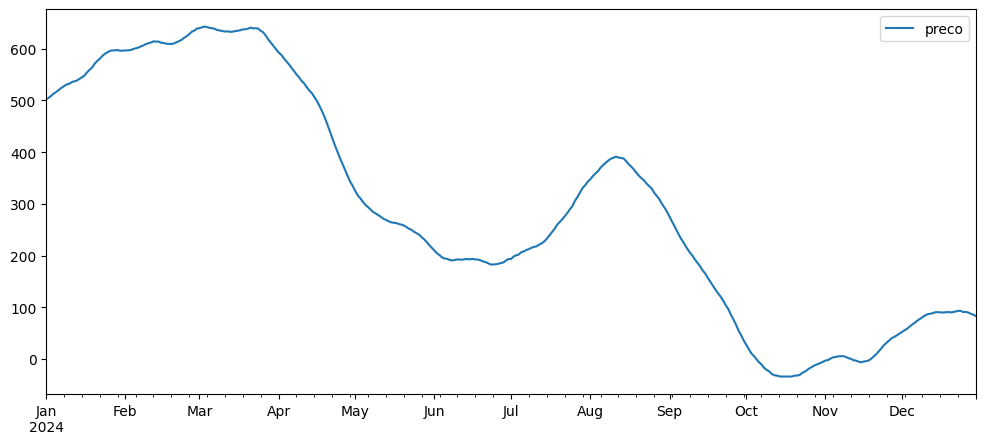

In [9]:
Y = pd.read_csv('/Users/danielferreira/Documents/git/classes/ASN/Séries Temporais/dados/ARIMA_Exemplo.csv')
Y.index = pd.date_range(start='2024-01-01', periods = 365)
Y.plot()
plt.show()

                               SARIMAX Results                                
Dep. Variable:                  preco   No. Observations:                  365
Model:               ARIMA(2, 1, [3])   Log Likelihood                -515.275
Date:                Tue, 25 Mar 2025   AIC                           1038.549
Time:                        17:25:52   BIC                           1054.138
Sample:                    01-01-2024   HQIC                          1044.745
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4931      0.047     10.540      0.000       0.401       0.585
ar.L2          0.4567      0.048      9.528      0.000       0.363       0.551
ma.L3          0.9217      0.023     39.346      0.0

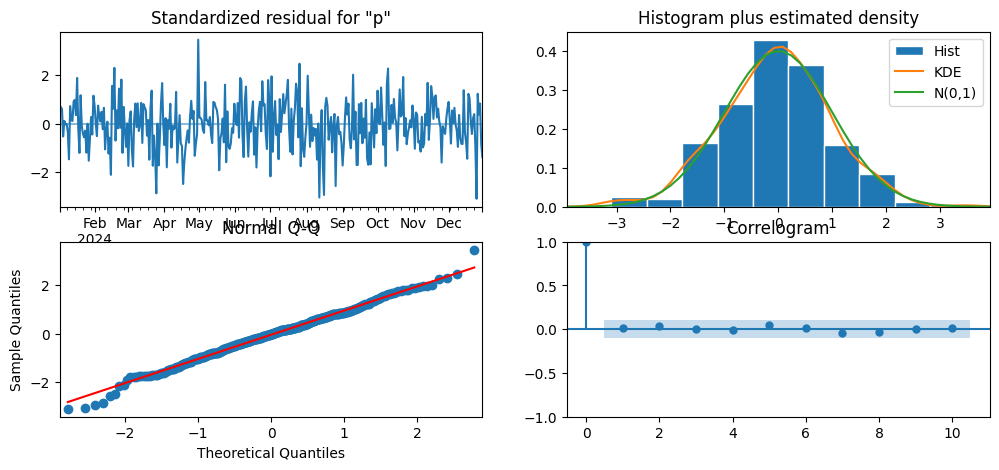

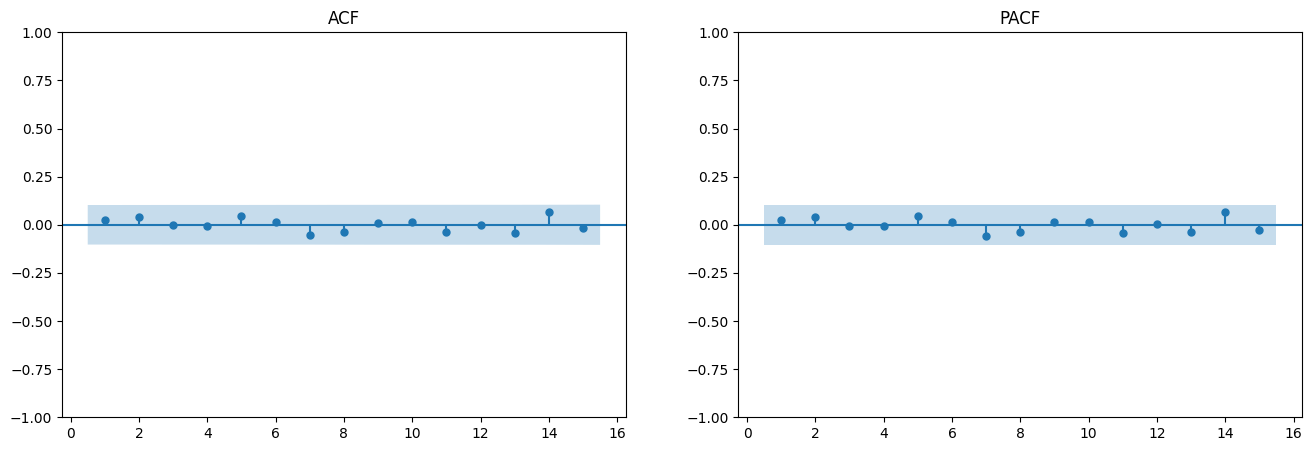

In [10]:
model = ARIMA(Y, order=(2, 1, (0,0,1))).fit()
diagnostico(model)

In [11]:
print(f"AIC: {model.aic}")
print(f"BIC: {model.bic}")
print(f"AICC: {model.aicc}")
print(f"HQIC: {model.hqic}")

AIC: 1038.5493263528415
BIC: 1054.1379418233885
AICC: 1038.6607469656549
HQIC: 1044.745085066488


In [12]:
model = ARIMA(Y, order=(2, 1, 3)).fit()
print(f"AIC: {model.aic}")
print(f"BIC: {model.bic}")
print(f"AICC: {model.aicc}")
print(f"HQIC: {model.hqic}")

AIC: 1041.1780582666204
BIC: 1064.5609814724407
AICC: 1041.4133523842675
HQIC: 1050.4716963370902


## Auto ARIMA

In [13]:
auto_model = pm.auto_arima(milk_prod, information_criterion='oob', scoring='mse', out_of_sample_size=24 )

In [14]:
auto_model = pm.auto_arima(milk_prod, 
                           seasonal=True, 
                           m=12, 
                           test='adf', 
                           information_criterion='aic',
                           trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=1070.222, Time=0.62 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1119.969, Time=0.01 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1081.584, Time=0.04 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1066.296, Time=0.07 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=1114.995, Time=0.01 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=1068.030, Time=0.11 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=1067.976, Time=0.26 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1082.123, Time=0.04 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=inf, Time=0.70 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=1072.280, Time=0.04 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=1068.064, Time=0.10 sec
 ARIMA(0,1,2)(0,1,1)[12]             : AIC=1067.796, Time=0.08 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=1066.207, Time=0.07 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1114.845, Time=0.01 sec
 ARIMA(1,1,0)(1,1,1)[12]

In [15]:
auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  168
Model:             SARIMAX(1, 1, 0)x(0, 1, [1], 12)   Log Likelihood                -530.104
Date:                              Tue, 25 Mar 2025   AIC                           1066.207
Time:                                      17:25:56   BIC                           1075.337
Sample:                                  01-01-1962   HQIC                          1069.916
                                       - 12-01-1975                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2253      0.077     -2.925      0.003      -0.376      -0.074
ma.S.L12      -0.6190      0.070     -8.825      0.000      -0.757      -0.482
sigma2        52.6908      4.897     10.759      0.000      43.093      62.289
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                35.11
Prob(Q):                              0.91   Prob(JB):                         0.00
Heteroskedasticity (H):               0.82   Skew:                             0.74
Prob(H) (two-sided):                  0.49   Kurtosis:                         4.80
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

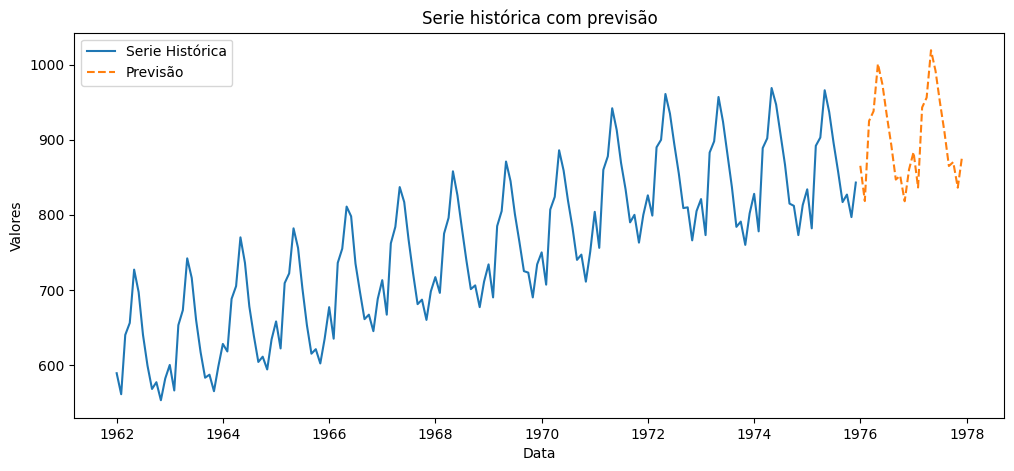

In [16]:
forecasts = auto_model.predict(n_periods=24)
plot_forecast(milk_prod,forecasts)